# Segment Level Results

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../RESULTS/SEGMENT_LEVEL_RESULTS.csv")


C:\Users\ritaw\AppData\Local\Temp\ipykernel_12040\1540486665.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../RESULTS/SEGMENT_LEVEL_RESULTS.csv")


In [60]:
df.columns

Index(['windows', 'percentile', 'config', 'C', 'gamma', 'patient', 'record',
       'n_windows', 'n_seizure_windows', 'record_length', 'threshold', 'k',
       'roc_auc', 'ap', 'seg_accuracy', 'seg_specificity', 'seg_sensitivity',
       'seg_precision', 'seg_f1', 'tp', 'fp', 'fn', 'windows.1'],
      dtype='object')

In [61]:
df["gamma"] = df["gamma"].astype(str)

## 1. Summary table across all configs

In [62]:
# ==========================
# Pooled segment-level table
# ==========================

segment_results = (
    df
    .groupby(
        [
            "windows",
            "config",
            "C",
            "gamma",
            "percentile"
        ]
    )
    .agg(
        # discrimination
        AUC=("roc_auc", "mean"),
        AUC_std=("roc_auc", "std"),
        AP=("ap", "mean"),

        # pooled counts
        TP=("tp", "sum"),
        FP=("fp", "sum"),
        FN=("fn", "sum"),

        # segment metrics
        specificity=("seg_specificity", "mean")
    )
    .reset_index()
)


# pooled sensitivity
segment_results["segment_sensitivity"] = (
    segment_results["TP"] /
    (segment_results["TP"] + segment_results["FN"])
)


# pooled precision
segment_results["segment_precision"] = (
    segment_results["TP"] /
    (segment_results["TP"] + segment_results["FP"])
)


segment_results

,windows,config,C,gamma,percentile,AUC,AUC_std,AP,TP,FP,FN,specificity,segment_sensitivity,segment_precision
0,0,A10,0.1,scale,10,0.880656,0.135847,0.369443,2417,137079,2052,0.944046,0.540837,0.017327
1,0,A5,0.1,scale,5,0.871165,0.143139,0.339077,2502,169045,1967,0.930256,0.559857,0.014585
2,0,B10,0.1,0.01,10,0.872530,0.139399,0.344784,2029,114264,2440,0.957463,0.454017,0.017447
3,0,B5,0.1,0.01,5,0.874595,0.141678,0.349765,2684,184291,1785,0.920753,0.600582,0.014355
4,0,C10,0.1,0.001,10,0.886720,0.134840,0.370462,3144,240243,1325,0.878772,0.703513,0.012918
5,0,C5,0.1,0.001,5,0.878946,0.141528,0.356697,3194,311787,1275,0.856872,0.714701,0.010140
6,0,D10,0.1,0.0001,10,0.872114,0.146939,0.344225,3118,384003,1351,0.828869,0.697695,0.008054
7,0,D5,0.1,0.0001,5,0.865156,0.153810,0.339114,3050,415288,1419,0.828361,0.682479,0.007291
8,0,E10,1.0,scale,10,0.877488,0.141475,0.395677,1428,23817,3041,0.987730,0.319535,0.056566
9,0,E5,1.0,scale,5,0.867923,0.143899,0.344448,1315,38293,3154,0.979766,0.294249,0.033200


In [63]:
segment_results.to_csv("../SEGMENT/SEGMENT_LEVEL_RESULTS_POOLED.csv", index=False)

> Across all configurations and evaluated sampling strategies, ROC-AUC remained within a narrow range (X-Y). The limited variation across C, $\gamma$, percentile and sampling strategy indicates that the spectral GC feature representation consistently capture information that separates ictal and interictal windows in general.

## 2. Ranges across grid

In [82]:
segment_summary = (
    segment_results
    .groupby(["windows","percentile"])
    .agg(
        AUC_mean=("AUC","mean"),
        AUC_std=("AUC","std"),
        AUC_min=("AUC","min"),
        AUC_max=("AUC","max"),

        AP_mean=("AP","mean"),
        AP_std=("AP","std"),
        AP_min=("AP","min"),
        AP_max=("AP","max"),

        sensitivity_mean=("segment_sensitivity","mean"),
        sensitivity_std=("segment_sensitivity","std"),
        sensitivity_min=("segment_sensitivity","min"),
        sensitivity_max=("segment_sensitivity","max"),

        specificity_mean=("specificity","mean"),
        specificity_std=("specificity","std"),
        specificity_min=("specificity","min"),
        specificity_max=("specificity","max"),

        precision_mean=("segment_precision","mean"),
        precision_std=("segment_precision","std"),
        precision_min=("segment_precision","min"),
        precision_max=("segment_precision","max")
    )
    .reset_index()
)

segment_summary

,windows,percentile,AUC_mean,AUC_std,AUC_min,AUC_max,AP_mean,AP_std,AP_min,AP_max,...,sensitivity_min,sensitivity_max,specificity_mean,specificity_std,specificity_min,specificity_max,precision_mean,precision_std,precision_min,precision_max
0,0,5,0.870733,0.006986,0.859385,0.879176,0.353223,0.010029,0.339077,0.368139,...,0.215261,0.714701,0.920546,0.056832,0.828361,0.992136,0.023943,0.018066,0.007291,0.061014
1,0,10,0.877014,0.009386,0.858107,0.887701,0.374878,0.018067,0.344225,0.401066,...,0.160215,0.711569,0.939092,0.055989,0.828869,0.997651,0.040796,0.037917,0.008054,0.115652
2,10000,5,0.867611,0.007744,0.853207,0.876339,0.354649,0.012928,0.330399,0.371472,...,0.177668,0.712240,0.927448,0.060254,0.809018,0.995495,0.042756,0.033909,0.010571,0.114376
3,10000,10,0.870162,0.006829,0.855042,0.879031,0.383685,0.015122,0.353319,0.405900,...,0.142537,0.713582,0.945681,0.056547,0.823810,0.998499,0.084305,0.082964,0.013166,0.257062


In [83]:
pd.set_option("display.max_columns", None)

segment_summary

,windows,percentile,AUC_mean,AUC_std,AUC_min,AUC_max,AP_mean,AP_std,AP_min,AP_max,sensitivity_mean,sensitivity_std,sensitivity_min,sensitivity_max,specificity_mean,specificity_std,specificity_min,specificity_max,precision_mean,precision_std,precision_min,precision_max
0,0,5,0.870733,0.006986,0.859385,0.879176,0.353223,0.010029,0.339077,0.368139,0.524483,0.191131,0.215261,0.714701,0.920546,0.056832,0.828361,0.992136,0.023943,0.018066,0.007291,0.061014
1,0,10,0.877014,0.009386,0.858107,0.887701,0.374878,0.018067,0.344225,0.401066,0.480048,0.205740,0.160215,0.711569,0.939092,0.055989,0.828869,0.997651,0.040796,0.037917,0.008054,0.115652
2,10000,5,0.867611,0.007744,0.853207,0.876339,0.354649,0.012928,0.330399,0.371472,0.496215,0.198990,0.177668,0.712240,0.927448,0.060254,0.809018,0.995495,0.042756,0.033909,0.010571,0.114376
3,10000,10,0.870162,0.006829,0.855042,0.879031,0.383685,0.015122,0.353319,0.405900,0.450511,0.207266,0.142537,0.713582,0.945681,0.056547,0.823810,0.998499,0.084305,0.082964,0.013166,0.257062


In [84]:
segment_summary.to_csv("../SEGMENT/SEGMENT_LEVEL_RESULTS_SUMMARY.csv", index=False)

## 3. AUC Distribution

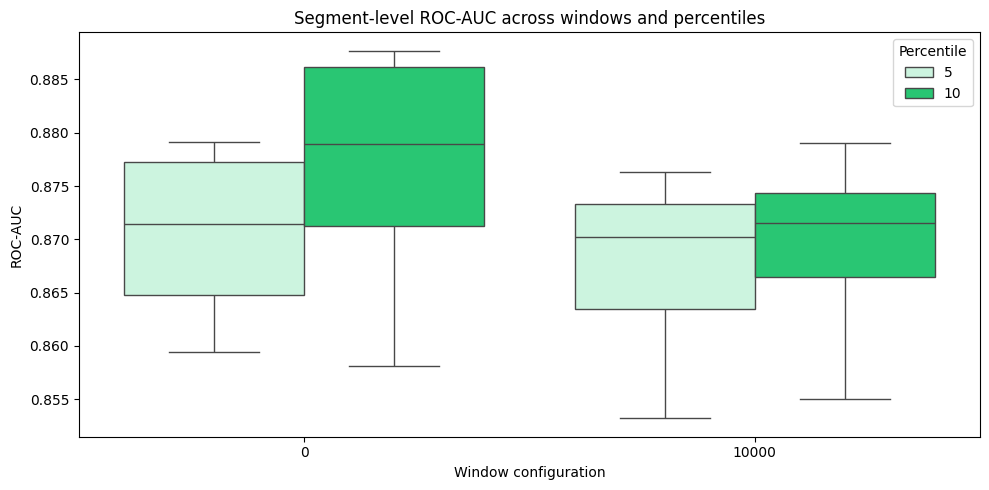

In [81]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=segment_results,
    x="windows",
    y="AUC",
    hue="percentile",
     palette=["#c5fbde", "#0fe071"]  
    
)

plt.xlabel("Window configuration")
plt.ylabel("ROC-AUC")

plt.title(
    "Segment-level ROC-AUC across windows and percentiles"
)

plt.legend(title="Percentile")
plt.tight_layout()
plt.show()

## 4. C x gamma heatmap

> This is to results if the results were driven by the C/gamma?

In [67]:
from matplotlib.colors import LinearSegmentedColormap


uni_green = LinearSegmentedColormap.from_list(
    "uni_green",
    [
        "#ffffff",
        "#0fe071"
    ]
)


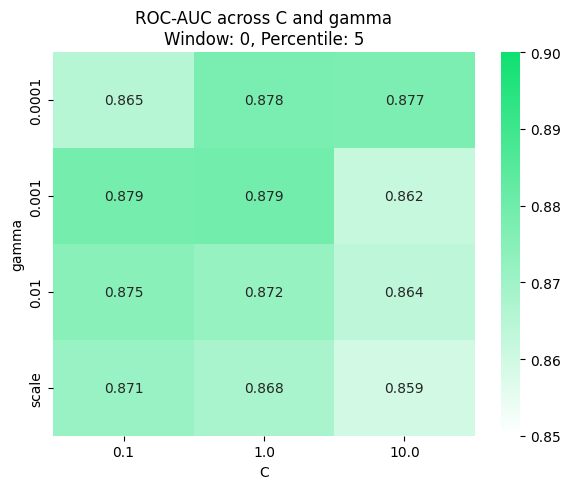

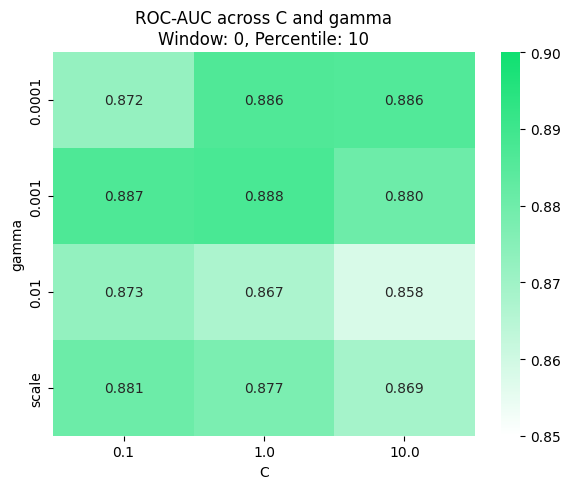

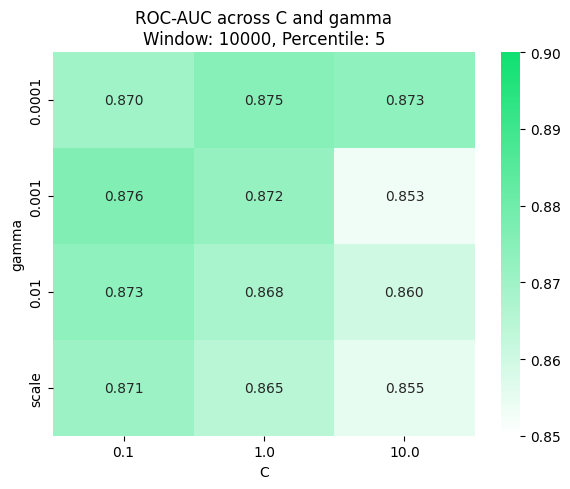

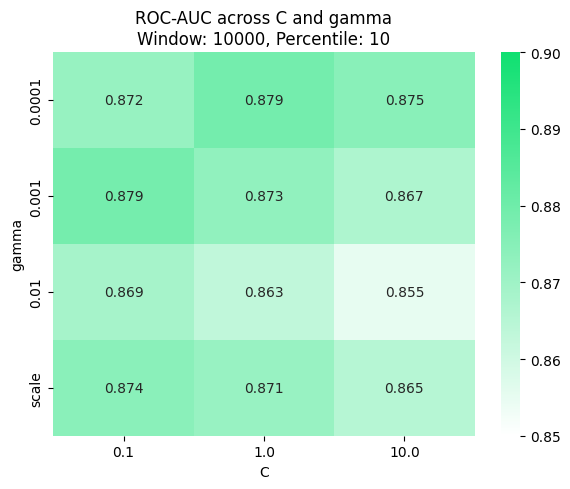

In [68]:
for (window, percentile), temp in segment_results.groupby(
    ["windows", "percentile"]
):

    heat = (
        temp
        .groupby(["C", "gamma"])["AUC"]
        .mean()
        .reset_index()
    )

    heat = heat.pivot(
        index="gamma",
        columns="C",
        values="AUC"
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        heat,
        annot=True,
        fmt=".3f",
        cmap=uni_green,
        vmin=0.85,
        vmax=0.90
    )

    plt.title(
        f"ROC-AUC across C and gamma\nWindow: {window}, Percentile: {percentile}"
    )

    plt.xlabel("C")
    plt.ylabel("gamma")

    plt.tight_layout()
    plt.show()

> The similarity in AUC values across the C and γ search space suggests that the classifier performance was relatively insensitive to the evaluated SVM regularisation and kernel parameters. Which means that the model does not require a narrowly tuned parameter combination to achieve comparable separation.

## 5. Average Precision Distribution

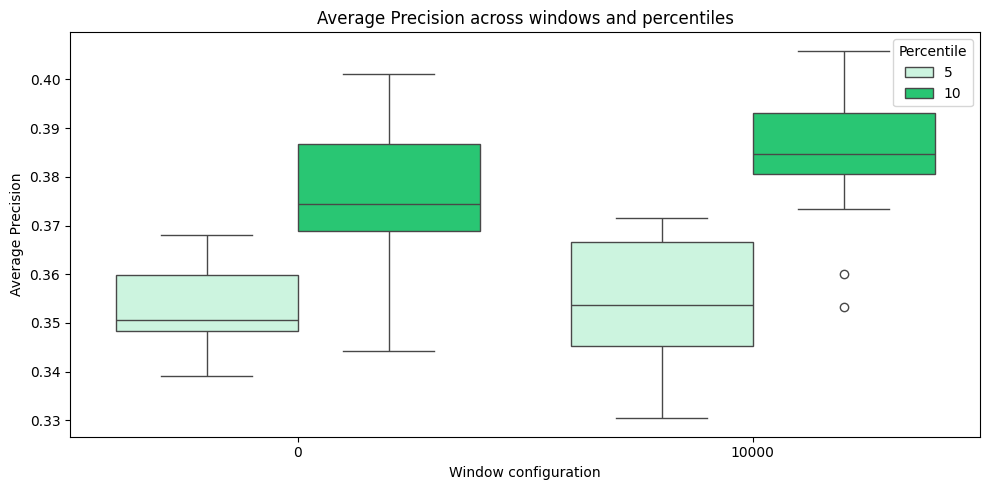

In [80]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=segment_results,
    x="windows",
    y="AP",
    hue="percentile",
    palette=["#c5fbde", "#0fe071"]   # add more if you have more percentiles
)

plt.xlabel("Window configuration")
plt.ylabel("Average Precision")

plt.title(
    "Average Precision across windows and percentiles"
)

plt.legend(title="Percentile")

plt.tight_layout()
plt.show()